In [1]:
import sympy as sp
import numpy as np
from scipy.special import ellipk
from scipy.constants import epsilon_0, mu_0
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

from pyCircFit_main import *

In [2]:
def circle_fit(freq,re,im,power,plotResults=True):

    # adapted from Kaushal's code to circle fit S21 data 
    amp_array = re+1j*im
    phase = np.unwrap(np.angle(amp_array))

    phase_corr=False
    if phase_corr:
        phase = np.unwrap(np.angle(amp_array))
        line_delay = (phase[0]-phase[-1])/(freq[0]-freq[-1])
        phase_corr_array = -phase[0]-line_delay*(freq-freq[0])
        amp_corr_array = amp_array * np.exp(1j*phase_corr_array)
        q_corr = np.imag(amp_corr_array)
        i_corr = np.real(amp_corr_array)
        mag_corr = np.sqrt(q_corr**2 + i_corr**2)
        phase_correct = np.unwrap(np.angle(amp_corr_array))
        plt.figure(11)
        plt.scatter(freq,10*np.log10(mag_corr))
        plt.figure(22)
        plt.scatter(freq,phase_correct)
        plt.figure(33)
        plt.scatter(i_corr,q_corr)
        plt.gca().set_aspect('equal')
        cresults = circlefit(freq/1e6, i_corr, q_corr,fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
        fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
    
    i_corr = re
    q_corr = im
    cresults = circlefit(freq/1e6, re, im, fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
    fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
        
        # from Kaushal's code to calculate photon number 
    h = 6.63*1e-34
    q = np.abs(cresults['Qtot'])
    q_err = cresults['Qtot_stderr']
    qc = cresults['Qc']
    qc_err = np.abs(cresults['Qc_stderr'])
    qi = cresults['Qi']
    qi_err = np.abs(cresults['Qi_stderr'])
    f = cresults['fr']*1e6
    f_err = cresults['fr_stderr']
    a = cresults['a']

    # plotting results 
    if (plotResults):
        ## from Kaushal's code to plot circle fit
        plt.figure(figsize=(6,6))
        plt.scatter(i_corr, q_corr, label= 'IQ data', s=12)
        plt.plot(np.real(fit_data), np.imag(fit_data), label='IQ fit', linewidth=6, color='C2')
        plt.legend(fontsize=14, loc='upper right')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel('I (a.u.)', fontsize=12)
        plt.ylabel('Q (a.u.)', fontsize=12)
        plt.title(r'$\bf{f}$'+f' = {np.round(cresults["fr"]*1e-3,4)} GHz' + r'$\pm $' + 
            f'{np.round(cresults['fr_stderr']*1e3,1)} KHz,' + r'$\bf{Q}_i$' + f' = {np.abs(np.round(cresults["Qi"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qi_stderr'],1)},'  + r'$\bf{Q}_c$' + f' = {np.abs(np.round(cresults["Qc"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qc_stderr'],1)}', fontsize=12)
        plt.gca().set_aspect('equal')
        plt.show()
    
    #returns results for quantities
    return q,q_err,qc,qc_err,qi,qi_err,f,f_err,a

In [3]:
# Plotting preferences.
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

# Define color scheme: grey to black.
def make_colors(n,name='summer'):
    cmap = cm.get_cmap(name)
    values = np.linspace(0, 1, n)
    colors = cmap(values)
    return colors

In [4]:
"""
Physical constants. 
"""
EPS_R_SAPPHIRE = 9.6 # Sapphire dielectric constant.
EPS_R_hBN = 2.8

In [5]:
# Coplanar capacitance and inductance for center pin of resonator.
def cpw_LC(w,g,sheet_ind):
    # Half in air and half in sapphire.
    eps_eff = 0.5 * (EPS_R_SAPPHIRE + 1)

    # Elliptic modulus.
    k = w / (w + 2*g)
    m = k**2
    m_prime = 1 - m

    # Complete elliptic integrals.
    K_k = ellipk(m)
    K_kprime = ellipk(m_prime)

    # Per-unit-length quantities.
    C_per_length = 4 * epsilon_0 * eps_eff * (K_k / K_kprime)
    L_per_length = (mu_0 / 4) * (K_kprime / K_k) + sheet_ind/w # Plus sheet inductance per unit length.
    z0 = np.sqrt(L_per_length/C_per_length) # Characteristic impedance of resonator.

    print("C':", C_per_length)
    print("L':", L_per_length)
    print('Z0:',z0)

    return C_per_length, L_per_length, z0

def add_in_series(*Zs):
    return sum(Zs)

def add_in_parallel(*Zs):
    return 1/sum(1/Z for Z in Zs)

def zin_terminated_res(z0,zload,prop_constant):
    zin = z0 * (zload + z0 * np.tanh(prop_constant)) / (z0 + zload * np.tanh(prop_constant))
    return zin

def zin_unloaded_res_lamda2(z0,prop_constant):
    return z0/np.tanh(prop_constant)

def zin_unloaded_res_lamda4(z0,prop_constant):
    return z0*np.tanh(prop_constant)
    

In [6]:
# Transmission line impedance.
sheet_ind = 1e-12 # Starting with 100pH sheet inductance.
center_pin_width = 8e-6
ground_plane_gap = 2e-6

feedline_C = 20e-15 # 30fF coupling to feedline.
z_feedline = 50 # Impedance of feedline.

# Find characteristic impedance of resonator based on coplanar waveguide geometry.
C_per_length, L_per_length, z0 = cpw_LC(center_pin_width,ground_plane_gap,sheet_ind)
print(f"Characteristic impedance is: {z0}.")

C': 1.7838624763808682e-10
L': 4.5557734972122105e-07
Z0: 50.53594332159731
Characteristic impedance is: 50.53594332159731.


In [7]:
"""
Estimate coupling to feedline as parallel plate capacitance. I think there is also some inductive coupling.
"""
eps_eff = 0.5 * (EPS_R_SAPPHIRE + 1) * epsilon_0

In [8]:
import matplotlib as mpl
def colorset(n, cmap="magma", *, lo=0.0, hi=1.0, hex=False, reverse=False):
    """N evenly spaced colors from a colormap.

    lo, hi   restrict the range sampled (0–1) to trim washed-out ends.
    hex      return '#rrggbb' strings instead of RGBA tuples.
    """
    if n < 1:
        raise ValueError(f"n must be >= 1, got {n}")
    cm = mpl.colormaps[cmap]
    pts = np.full(1, (lo + hi) / 2) if n == 1 else np.linspace(lo, hi, n)
    if reverse:
        pts = pts[::-1]
    cols = cm(pts)
    return [mpl.colors.to_hex(c) for c in cols] if hex else cols

C:\Users\emmag\AppData\Local\Temp\ipykernel_9516\1090379785.py:26: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1,figsize=(10,5))


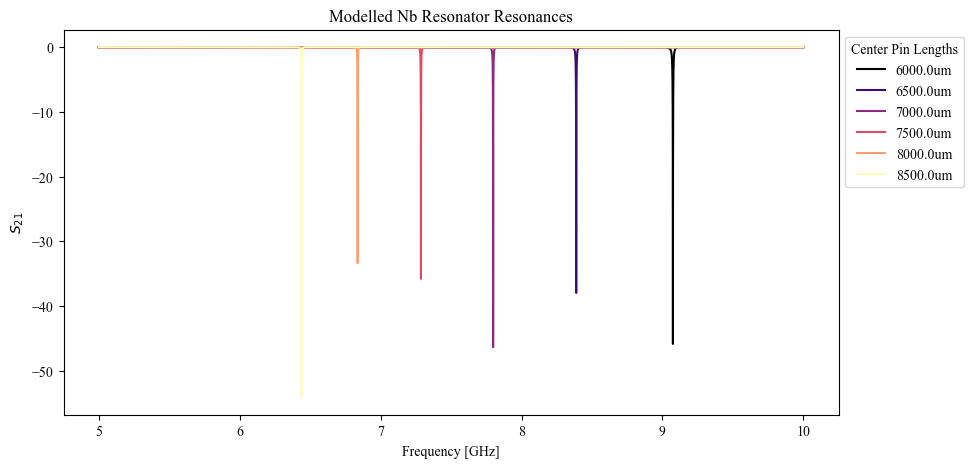

In [9]:
f=np.linspace(5e9,10e9,int(5e4))
omegas = 2 * np.pi * f
center_pin_lengths = [6000e-6,6500e-6,7000e-6,7500e-6,8000e-6,8500e-6]
colors = colorset(len(center_pin_lengths))
for idx in range(len(center_pin_lengths)):
# for center_pin_length in [6000e-6]:
    center_pin_length = center_pin_lengths[idx]
    color = colors[idx]
    s21_mags = []
    s21_phases = []
    for omega in omegas:

        beta = 1j*omega*np.sqrt(C_per_length*L_per_length)
        prop_constant = beta*center_pin_length

        zin = zin_unloaded_res_lamda2(z0,prop_constant)

        # Solve for impedance presented to transmission line through coupling capacitor.
        coupling_cap = 1/(1j*omega*feedline_C)
        z_coupled = add_in_series(coupling_cap,zin)

        s21 = 2*z_coupled/(2*z_coupled + z_feedline)
        s21_mags.append(10*np.log10(np.abs(s21)**2))
        s21_phases.append(np.angle(s21))

    plt.figure(1,figsize=(10,5))
    plt.plot(f/1e9,s21_mags,label=f'{np.round(center_pin_length*1e6,0)}um',color=color)
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("$S_{21}$")
    plt.legend(title='Center Pin Lengths',bbox_to_anchor=(1,1))
    plt.title("Modelled Nb Resonator Resonances")

C:\Users\emmag\AppData\Local\Temp\ipykernel_9516\3693977572.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


6.29


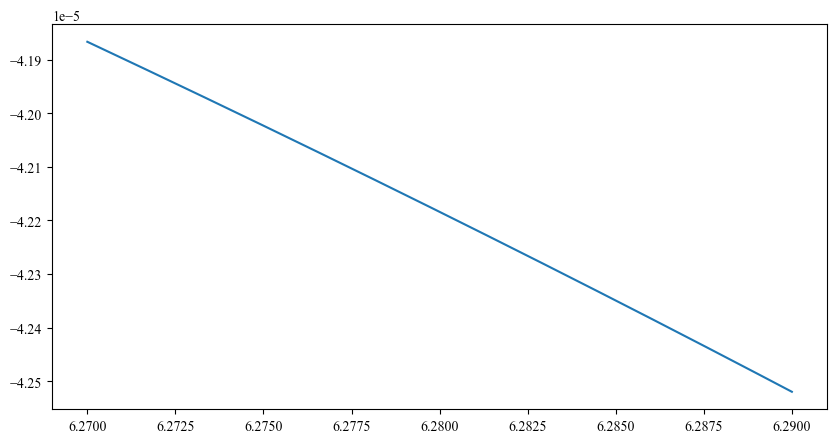

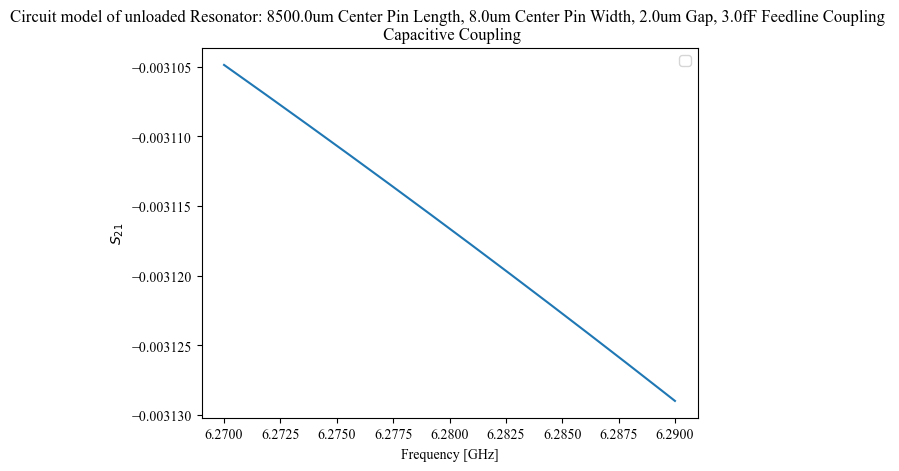

In [10]:
# Define frequencies of interest.
f=np.linspace(6.27e9,6.29e9,int(5e4))
omegas = 2 * np.pi * f

center_pin_length = 8500e-6

feedline_C = 3e-15 # 30fF coupling to feedline.
z_feedline = 50 # Impedance of feedline.

s21_mags = []
s21_phases = []
s21s = []
for omega in omegas:

    beta = 1j*omega*np.sqrt(C_per_length*L_per_length)
    prop_constant = beta*center_pin_length

    zin = zin_unloaded_res_lamda2(z0,prop_constant)

    # Solve for impedance presented to transmission line through coupling capacitor.
    coupling_cap = 1/(1j*omega*feedline_C)
    # coupling_cap = 100
    z_coupled = add_in_series(coupling_cap,zin)

    # Now find S21. Current flows in as I=V/Z and power is V*I, so solve for current through over current in.
    s21 = 2*z_coupled/(2*z_coupled + z_feedline)
    s21s.append(s21)
    s21_mags.append(20*np.log10(np.abs(s21)))
    s21_phases.append(np.angle(s21))

plt.figure(1,figsize=(10,5))
plt.plot(f/1e9,s21_mags)
plt.figure(2)
plt.plot(f/1e9,s21_phases)
plt.title(f"Circuit model of unloaded Resonator: {center_pin_length*1e6}um Center Pin Length, {center_pin_width*1e6}um Center Pin Width, {ground_plane_gap*1e6}um Gap, {feedline_C*1e15}fF Feedline Coupling \n Capacitive Coupling")
plt.xlabel("Frequency [GHz]")
plt.ylabel("$S_{21}$")
plt.legend()

print(f[np.argmin(s21_mags)]/1e9)

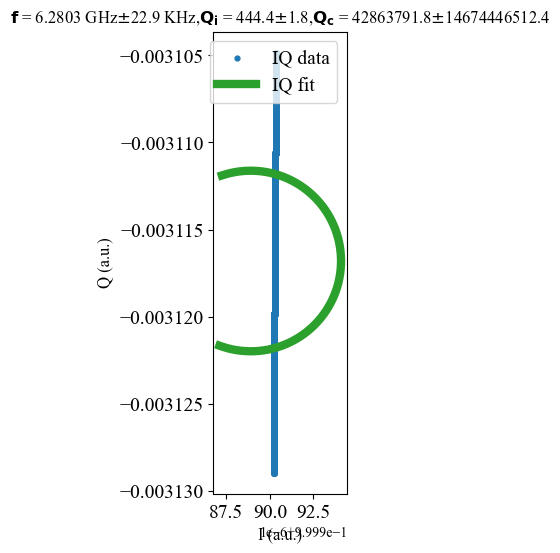

(np.float64(444.4184658832183),
 np.float64(0.7656853637790243),
 np.float64(42863791.8182853),
 np.float64(14674446512.352049),
 np.float64(444.4138624049155),
 np.float64(1.7521424568659643),
 np.float64(6280337461.785756),
 np.float64(0.022873035703163538),
 np.float64(0.9999885811311833))

In [11]:
circle_fit(f,np.real(s21s),np.imag(s21s),power=-80)

In [12]:
def lorentzian(f, f0, Q, A, offset):
    return offset + A * ((f0 / (2 * Q))**2) / ((f - f0)**2 + (f0 / (2 * Q))**2)

min_idx = np.argmin(s21_mags)

p0 = [f[min_idx],10000,1,0]
popt, pcov = curve_fit(lorentzian, f, np.abs(s21_mags),p0=p0,maxfev=2500)

plt.plot(f,s21_mags)
plt.plot(f,-lorentzian(f, *popt))

q_lorentz = popt[1]
print(f"Q is: {q_lorentz}.")

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 2500.

In [ ]:
""" 
Now load with sample impedance (starting with just dielectric and metal).
"""

# Sample dimensions are 4umx4um plus coupling.
# sample_len = 5e-6
# sample_width = 10e-6
# sample_num_squares = sample_len/sample_width

# sample_resonator_cap = 14e-15
# sample_ground_cap = 100e-15

# gate_resonator_cap = 322e-15
# gate_ground_cap = 44e-15

sample_num_squares = 0.2
sample_ind_per_sq = np.linspace(1e-9,100e-9,51)
sample_ind_arr = sample_num_squares*sample_ind_per_sq

gate_res_per_sq = 75
gate_resistance = gate_res_per_sq*sample_num_squares

res_ground_contact = 100e3

hbn_bottom_thickness = 15e-9
hbn_top_thickness = 10e-9

res_coupling_area = 33.5e-12
ground_coupling_area = 19e-12

gate_res_coupling_area = 4e-12
ground_res_coupling_area = 2e-12

sample_res_cap = epsilon_0*EPS_R_hBN*res_coupling_area/hbn_bottom_thickness
gate_sample_cap_res = epsilon_0*EPS_R_hBN*res_coupling_area/hbn_top_thickness
sample_ground_cap = epsilon_0*EPS_R_hBN*ground_coupling_area/hbn_bottom_thickness
gate_sample_cap_ground = epsilon_0*EPS_R_hBN*ground_coupling_area/hbn_top_thickness

gate_res_cap = epsilon_0*EPS_R_hBN*gate_res_coupling_area/(hbn_top_thickness+hbn_bottom_thickness)
gate_ground_cap = epsilon_0*EPS_R_hBN*ground_res_coupling_area/(hbn_top_thickness+hbn_bottom_thickness)

In [ ]:
print(sample_res_cap/1e-15)

55.368187826896


C:\Users\emmag\AppData\Local\Temp\ipykernel_22504\1929864652.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)


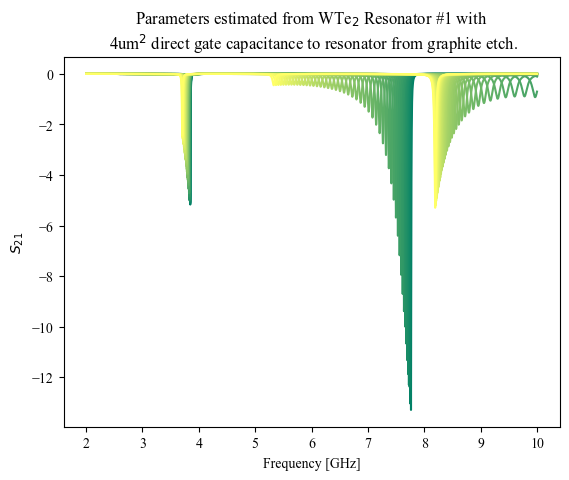

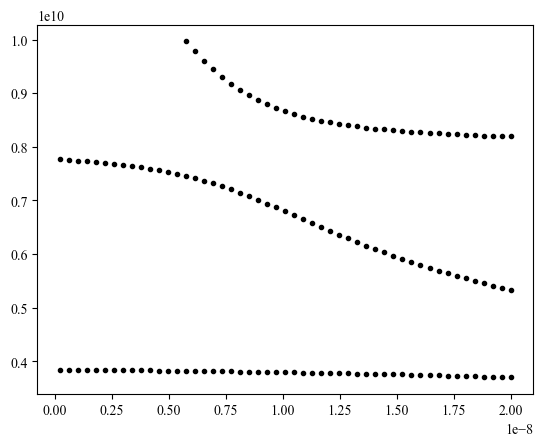

In [ ]:
# Define frequencies of interest.
f=np.linspace(2e9,10e9,int(5e3))
omegas = 2 * np.pi * f

colors = make_colors(len(sample_ind_arr))

f_min_arr = []
for i in range(len(sample_ind_arr)):
    s21_mags = []
    s21_phases = []
    c = colors[i]
    ind = sample_ind_arr[i]
    for omega in omegas:

        beta = 1j*omega*np.sqrt(C_per_length*L_per_length)
        prop_constant = beta*center_pin_length

        # Solve for sample impedance.
        sample_resonator_imp = 1/(1j*omega*sample_res_cap)
        sample_ground_imp = 1/(1j*omega*sample_ground_cap)
        sample_gate_imp_res = 1/(1j*omega*gate_sample_cap_res)
        sample_gate_imp_ground = 1/(1j*omega*gate_sample_cap_ground)
        gate_res_imp = 1/(1j*omega*gate_res_cap)
        gate_ground_imp = 1/(1j*omega*gate_ground_cap)
        sample_imp = 1j*omega*ind
        sample_gate_imp = add_in_series(sample_gate_imp_res,gate_resistance,sample_gate_imp_ground)
        z_sample = add_in_series(sample_resonator_imp,add_in_parallel(sample_imp,sample_gate_imp),add_in_parallel(sample_ground_imp,res_ground_contact))
        z_gate = add_in_series(gate_res_imp,gate_resistance,gate_ground_imp)

        z_term  = add_in_parallel(z_sample,z_gate)

        # Solve for input impedance of resonator terminated into load.
        zin = zin_terminated_res(z0,z_sample,prop_constant)

        # Solve for impedance presented to transmission line through coupling capacitor.
        coupling_cap = 1/(1j*omega*feedline_C)
        z_coupled = add_in_series(coupling_cap,zin)

        # Now find S21. Current flows in as I=V/Z and power is V*I, so solve for current through over current in.
        s21 = 2*z_coupled/(2*z_coupled + z_feedline)
        s21_mags.append(20*np.log10(np.abs(s21)))
        s21_phases.append(np.angle(s21))

    plt.figure(1)
    plt.plot(f/1e9,s21_mags,c=c,label=f"{ind}")
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("$S_{21}$")
    plt.title("Parameters estimated from WTe$_2$ Resonator #1 with \n 4um$^2$ direct gate capacitance to resonator from graphite etch.")

    # Now extract peaks.
    peak_idx = find_peaks(np.abs(s21_mags),height=0.2)[0]
    freq_peaks = [f[peak] for peak in peak_idx]
    ind_arr = ind*np.ones(len(freq_peaks))

    # Fix this bug! 
    plt.figure(2)
    plt.plot(ind_arr,freq_peaks,linestyle='',marker='.',color='k')
    f_min_arr.append(freq_peaks[0])

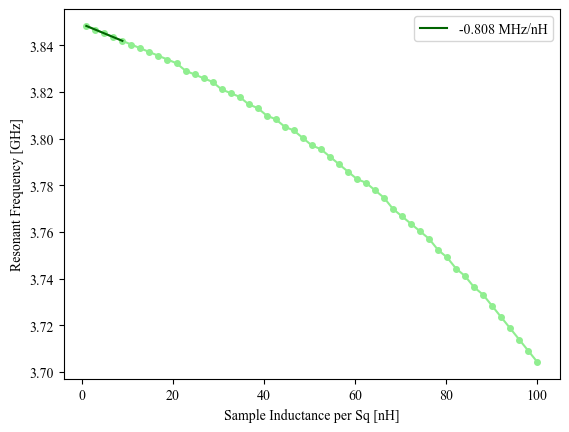

In [ ]:
m,b = np.polyfit(sample_ind_per_sq[:5]/1e-9,np.array(f_min_arr[:5])/1e9,1)
plt.plot(sample_ind_per_sq/1e-9,np.array(f_min_arr)/1e9,c='lightgreen',marker='o',linestyle='-',markersize=4)
plt.plot(sample_ind_per_sq[:5]/1e-9,m*np.array(sample_ind_per_sq[:5])/1e-9+b,linestyle='-',c='darkgreen',label=f'{np.round(1e3*m,3)} MHz/nH')
plt.xlabel("Sample Inductance per Sq [nH]")
plt.ylabel('Resonant Frequency [GHz]')
# plt.title("1/2 Square Sample, 9fF Coupling Capacitance, 64fF Ground Capacitance")
plt.legend()

### Now let's measure a resistive sample!

In [ ]:
sample_num_squares = 0.2
sample_res_per_sq = np.logspace(2,5,21)
sample_res_arr = sample_num_squares*sample_res_per_sq

gate_res_per_sq = 75
gate_resistance = gate_res_per_sq*sample_num_squares

res_ground_contact = 50e3

hbn_bottom_thickness = 15e-9
hbn_top_thickness = 10e-9

res_coupling_area = 33.5e-12
ground_coupling_area = 19e-12

gate_res_coupling_area = 4e-12
ground_res_coupling_area = 2e-12

sample_res_cap = epsilon_0*EPS_R_hBN*res_coupling_area/hbn_bottom_thickness
gate_sample_cap_res = epsilon_0*EPS_R_hBN*res_coupling_area/hbn_top_thickness
sample_ground_cap = epsilon_0*EPS_R_hBN*ground_coupling_area/hbn_bottom_thickness
gate_sample_cap_ground = epsilon_0*EPS_R_hBN*ground_coupling_area/hbn_top_thickness

gate_res_cap = epsilon_0*EPS_R_hBN*gate_res_coupling_area/(hbn_top_thickness+hbn_bottom_thickness)
gate_ground_cap = epsilon_0*EPS_R_hBN*ground_res_coupling_area/(hbn_top_thickness+hbn_bottom_thickness)

In [ ]:
# Transmission line impedance.
sheet_ind = 35e-12 # Starting with 100pH sheet inductance.
center_pin_width = 2e-6
ground_plane_gap = 60e-6
center_pin_length = 3500e-6

feedline_C = 15e-15 # 30fF coupling to feedline.
z_feedline = 50 # Impedance of feedline.

# Find characteristic impedance of resonator based on coplanar waveguide geometry.
C_per_length, L_per_length, z0 = cpw_LC(center_pin_width,ground_plane_gap,sheet_ind)
print(f"Characteristic impedance is: {z0}.")

C': 5.2625740902955714e-11
L': 1.8599420206198138e-05
Z0: 594.4982650751641
Characteristic impedance is: 594.4982650751641.


<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:77: SyntaxWarning: invalid escape sequence '\O'
C:\Users\emmag\AppData\Local\Temp\ipykernel_10404\2729839387.py:77: SyntaxWarning: invalid escape sequence '\O'
  plt.legend(bbox_to_anchor=(1,1),title='$\Omega/$sq',fontsize=8)
C:\Users\emmag\AppData\Local\Temp\ipykernel_10404\1929864652.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)


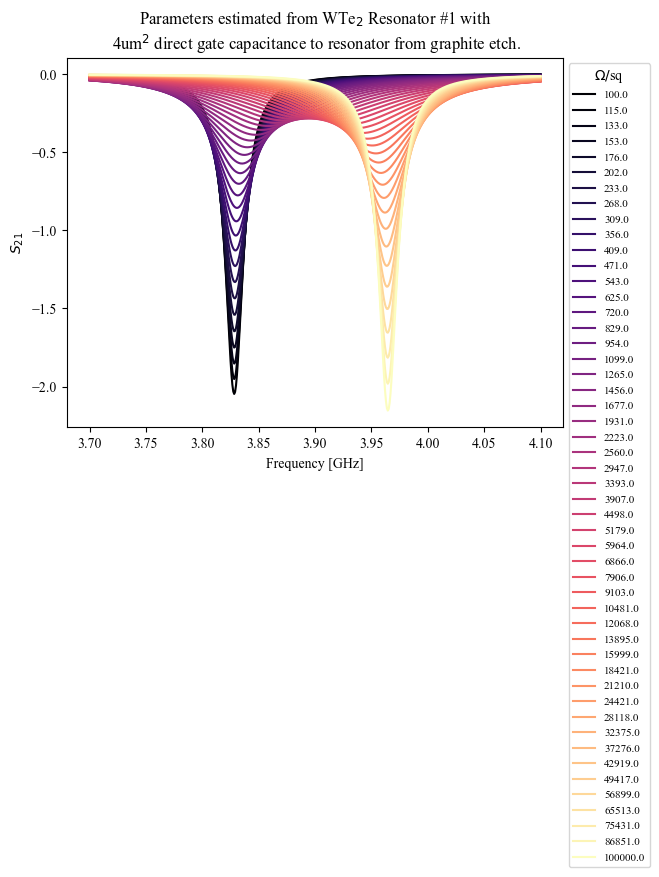

In [ ]:
sample_num_squares = 0.2
sample_res_per_sq = np.logspace(2,5,)
sample_res_arr = sample_num_squares*sample_res_per_sq

gate_res_per_sq = 75
gate_resistance = gate_res_per_sq*sample_num_squares

res_ground_contact = 50e3

hbn_bottom_thickness = 15e-9
hbn_top_thickness = 10e-9

res_coupling_area = 33.5e-12
ground_coupling_area = 19e-12

gate_res_coupling_area = 4e-12
ground_res_coupling_area = 2e-12

sample_res_cap = epsilon_0*EPS_R_hBN*res_coupling_area/hbn_bottom_thickness
gate_sample_cap_res = epsilon_0*EPS_R_hBN*res_coupling_area/hbn_top_thickness
sample_ground_cap = epsilon_0*EPS_R_hBN*ground_coupling_area/hbn_bottom_thickness
gate_sample_cap_ground = epsilon_0*EPS_R_hBN*ground_coupling_area/hbn_top_thickness

gate_res_cap = epsilon_0*EPS_R_hBN*gate_res_coupling_area/(hbn_top_thickness+hbn_bottom_thickness)
gate_ground_cap = epsilon_0*EPS_R_hBN*ground_res_coupling_area/(hbn_top_thickness+hbn_bottom_thickness)

# Define frequencies of interest.
f=np.linspace(3.7e9,4.1e9,int(500))
omegas = 2 * np.pi * f

colors = make_colors(len(sample_res_arr),name='magma')

f_min_arr = []
s21_arr = []
for i in range(len(sample_res_arr)):
    s21_mags = []
    s21_phases = []
    c = colors[i]
    res = sample_res_arr[i]
    for omega in omegas:

        beta = 1j*omega*np.sqrt(C_per_length*L_per_length)
        prop_constant = beta*center_pin_length

        # Solve for sample impedance.
        sample_resonator_imp = 1/(1j*omega*sample_res_cap)
        sample_ground_imp = 1/(1j*omega*sample_ground_cap)
        sample_gate_imp_res = 1/(1j*omega*gate_sample_cap_res)
        sample_gate_imp_ground = 1/(1j*omega*gate_sample_cap_ground)
        gate_res_imp = 1/(1j*omega*gate_res_cap)
        gate_ground_imp = 1/(1j*omega*gate_ground_cap)
        sample_imp = res
        sample_gate_imp = add_in_series(sample_gate_imp_res,gate_resistance,sample_gate_imp_ground)
        z_sample = add_in_series(sample_resonator_imp,add_in_parallel(sample_imp,sample_gate_imp),add_in_parallel(sample_ground_imp,res_ground_contact))
        z_gate = add_in_series(gate_res_imp,gate_resistance,gate_ground_imp)

        z_term  = add_in_parallel(z_sample,z_gate)

        # Solve for input impedance of resonator terminated into load.
        zin = zin_terminated_res(z0,z_term,prop_constant)

        # Solve for impedance presented to transmission line through coupling capacitor.
        coupling_cap = 1/(1j*omega*feedline_C)
        z_coupled = add_in_series(coupling_cap,zin)

        # Now find S21. Current flows in as I=V/Z and power is V*I, so solve for current through over current in.
        s21 = 2*z_coupled/(2*z_coupled + z_feedline)
        s21_mags.append(20*np.log10(np.abs(s21)))
        s21_phases.append(np.angle(s21))

    s21_arr.append(s21_mags)
    plt.figure(1)
    plt.plot(f/1e9,s21_mags,c=c,label=f"{np.round(sample_res_per_sq[i],0)}")
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("$S_{21}$")
    plt.title("Parameters estimated from WTe$_2$ Resonator #1 with \n 4um$^2$ direct gate capacitance to resonator from graphite etch.")
    plt.legend(bbox_to_anchor=(1,1),title='$\Omega/$sq',fontsize=8)

    # Now extract peaks.
    # peak_idx = find_peaks(np.abs(s21_mags),height=0.2)[0]
    # freq_peaks = [f[peak] for peak in peak_idx]
    # ind_arr = ind*np.ones(len(freq_peaks))

    # Fix this bug! 
    # plt.figure(2)
    # plt.plot(ind_arr,freq_peaks,linestyle='',marker='.',color='k')
    # f_min_arr.append(freq_peaks[0])

<>:60: SyntaxWarning: invalid escape sequence '\O'
<>:60: SyntaxWarning: invalid escape sequence '\O'
C:\Users\emmag\AppData\Local\Temp\ipykernel_9516\3445307313.py:60: SyntaxWarning: invalid escape sequence '\O'
  plt.legend(bbox_to_anchor=(1,1),title='$\Omega/$sq',fontsize=8)
C:\Users\emmag\AppData\Local\Temp\ipykernel_9516\1929864652.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)


C': 5.363777438185871e-11
L': 3.609942020619814e-05
Z0: 820.3793853369768
Characteristic impedance is: 820.3793853369768.


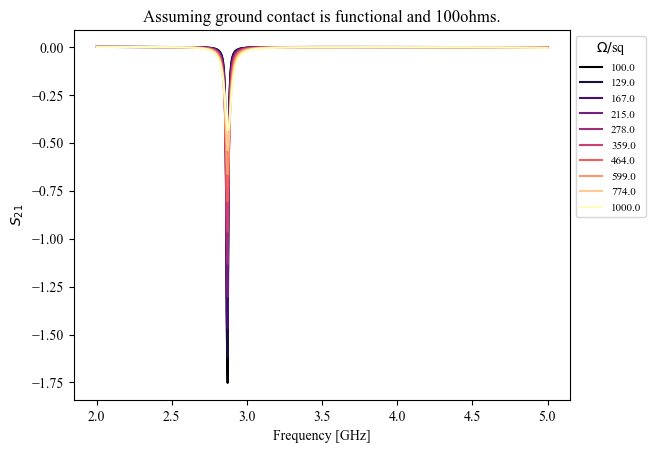

In [38]:
sheet_ind = 70e-12 # Starting with 100pH sheet inductance.
center_pin_width = 2e-6
ground_plane_gap = 60e-6
center_pin_length = 3500e-6

feedline_C = 15e-15 # 30fF coupling to feedline.
z_feedline = 50 # Impedance of feedline.

# Find characteristic impedance of resonator based on coplanar waveguide geometry.
C_per_length, L_per_length, z0 = cpw_LC(center_pin_width,ground_plane_gap,sheet_ind)
print(f"Characteristic impedance is: {z0}.")

sample_num_squares = 1
sample_res_per_sq = np.logspace(2,3,10)
sample_res_arr = sample_num_squares*sample_res_per_sq

sample_res_cap = 10e-15
res_ground_contact = 100

# Define frequencies of interest.
f=np.linspace(2e9,5e9,int(500))
omegas = 2 * np.pi * f

colors = make_colors(len(sample_res_arr),name='magma')

f_min_arr = []
s21_arr = []
for i in range(len(sample_res_arr)):
    s21_mags = []
    s21_phases = []
    c = colors[i]
    sample_res = sample_res_arr[i]
    for omega in omegas:

        beta = 1j*omega*np.sqrt(C_per_length*L_per_length)
        prop_constant = beta*center_pin_length

        # Solve for sample impedance.
        sample_resonator_imp = 1/(1j*omega*sample_res_cap)
        z_sample = add_in_series(sample_resonator_imp,sample_res,res_ground_contact)

        # Solve for input impedance of resonator terminated into load.
        zin = zin_terminated_res(z0,z_sample,prop_constant)

        # Solve for impedance presented to transmission line through coupling capacitor.
        coupling_cap = 1/(1j*omega*feedline_C)
        z_coupled = add_in_series(coupling_cap,zin)

        # Now find S21. Current flows in as I=V/Z and power is V*I, so solve for current through over current in.
        s21 = 2*z_coupled/(2*z_coupled + z_feedline)
        s21_mags.append(20*np.log10(np.abs(s21)))
        s21_phases.append(np.angle(s21))

    s21_arr.append(s21_mags)
    plt.figure(1)
    plt.plot(f/1e9,s21_mags,c=c,label=f"{np.round(sample_res_per_sq[i],0)}")
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("$S_{21}$")
    plt.title("Assuming ground contact is functional and 100ohms.")
    plt.legend(bbox_to_anchor=(1,1),title='$\Omega/$sq',fontsize=8)

    # Now extract peaks.
    # peak_idx = find_peaks(np.abs(s21_mags),height=0.2)[0]
    # freq_peaks = [f[peak] for peak in peak_idx]
    # ind_arr = ind*np.ones(len(freq_peaks))

    # Fix this bug! 
    # plt.figure(2)
    # plt.plot(ind_arr,freq_peaks,linestyle='',marker='.',color='k')
    # f_min_arr.append(freq_peaks[0])

<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
C:\Users\emmag\AppData\Local\Temp\ipykernel_10404\3510392814.py:4: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel("Sample Resistance per Sq (k$\Omega$)")


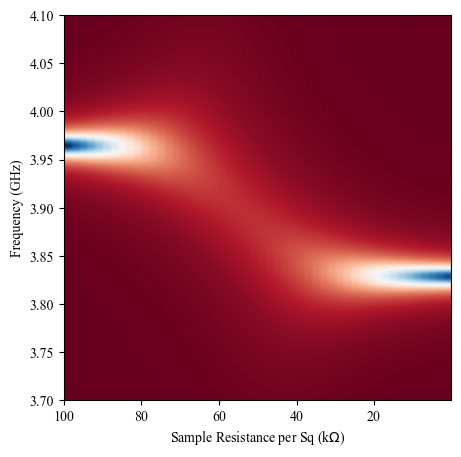

In [125]:
fig,ax = plt.subplots(1,figsize=(5,5))
ax.imshow(np.array(s21_arr).T,aspect='auto',extent=(sample_res_per_sq[0]/1e3,sample_res_per_sq[-1]/1e3,3.7,4.1),origin='lower',cmap='RdBu_r')
ax.set_ylabel("Frequency (GHz)")
ax.set_xlabel("Sample Resistance per Sq (k$\Omega$)")
plt.gca().invert_xaxis() 
plt.show()

In [73]:
arr1

[[1, 2, 3], [4, 5, 6]]